In [1]:
import pandas as pd

# Sample telecom KPI data
df = pd.DataFrame({
    "cell_name": ["Cell_A", "Cell_B", "Cell_C"],
    "latency_ms": [15, 50, 120],
    "packet_loss": [0.1, 1.5, 8],
    "throughput_mbps": [120, 70, 20],
    "prb_utilization": [60, 75, 98]
})

print(df)

  cell_name  latency_ms  packet_loss  throughput_mbps  prb_utilization
0    Cell_A          15          0.1              120               60
1    Cell_B          50          1.5               70               75
2    Cell_C         120          8.0               20               98


In [3]:
def calculate_health_score(row):

    # Start with a perfect score
    score = 100

    # Latency penalty
    score = score - (row["latency_ms"] * 0.2)

    # Packet loss penalty
    score = score - (row["packet_loss"] * 5)

    # Throughput penalty
    score = score - ((150 - row["throughput_mbps"]) * 0.2)

    # PRB penalty
    score = score - (row["prb_utilization"] * 0.1)

    # Prevent negative scores
    score = max(score, 0)

    return round(score, 2)

In [4]:
df["health_score"] = df.apply(
    calculate_health_score,
    axis=1
)

In [5]:
print(df)

  cell_name  latency_ms  packet_loss  throughput_mbps  prb_utilization  \
0    Cell_A          15          0.1              120               60   
1    Cell_B          50          1.5               70               75   
2    Cell_C         120          8.0               20               98   

   health_score  
0          84.5  
1          59.0  
2           0.2  


In [6]:
# Function to convert health score into a human-friendly remark
def get_remark(score):

    # Score between 90 and 100
    # Cell is performing extremely well
    if score >= 90:
        return "Excellent"

    # Score between 75 and 89
    # Cell is healthy but has some room for improvement
    elif score >= 75:
        return "Good"

    # Score between 50 and 74
    # Cell requires attention
    elif score >= 50:
        return "Warning"

    # Anything below 50
    # Cell is in poor condition
    else:
        return "Critical"

In [7]:
# Create a new column called remark
# For each row, look at the health score
# Then convert it into a category

df["remark"] = df["health_score"].apply(
    get_remark
)

# Display results
print(df)

  cell_name  latency_ms  packet_loss  throughput_mbps  prb_utilization  \
0    Cell_A          15          0.1              120               60   
1    Cell_B          50          1.5               70               75   
2    Cell_C         120          8.0               20               98   

   health_score    remark  
0          84.5      Good  
1          59.0   Warning  
2           0.2  Critical  


In [8]:
df["health_score"].apply(get_remark)

0        Good
1     Warning
2    Critical
Name: health_score, dtype: object

In [9]:
# Function to determine investigation priority
# based on the health score of the cell

def get_priority(score):

    # Critical cells need immediate attention
    if score < 50:
        return "High"

    # Warning cells should be checked soon
    elif score < 75:
        return "Medium"

    # Good and Excellent cells are lower priority
    else:
        return "Low"

In [10]:
# Create a new column called priority
# The health score of each cell is sent to get_priority()

df["priority"] = df["health_score"].apply(
    get_priority
)

# Display the updated DataFrame
print(df)

  cell_name  latency_ms  packet_loss  throughput_mbps  prb_utilization  \
0    Cell_A          15          0.1              120               60   
1    Cell_B          50          1.5               70               75   
2    Cell_C         120          8.0               20               98   

   health_score    remark priority  
0          84.5      Good      Low  
1          59.0   Warning   Medium  
2           0.2  Critical     High  


In [11]:
# Sort cells by health score
# Lowest score appears first
# Worst cells appear at the top

df_sorted = df.sort_values(
    by="health_score",
    ascending=True
)

# Display sorted results
print(df_sorted)

  cell_name  latency_ms  packet_loss  throughput_mbps  prb_utilization  \
2    Cell_C         120          8.0               20               98   
1    Cell_B          50          1.5               70               75   
0    Cell_A          15          0.1              120               60   

   health_score    remark priority  
2           0.2  Critical     High  
1          59.0   Warning   Medium  
0          84.5      Good      Low  


In [12]:
# Function to determine the likely root cause
# based on telecom KPI thresholds

def get_root_cause(row):

    # Create an empty list
    # We will store all detected problems here
    issues = []

    # Check latency KPI
    # Values above 40 ms may indicate delay problems
    if row["latency_ms"] > 40:
        issues.append("High Latency")

    # Check packet loss KPI
    # Values above 1% may impact voice/video quality
    if row["packet_loss"] > 1:
        issues.append("Packet Loss")

    # Check throughput KPI
    # Low throughput means poor user experience
    if row["throughput_mbps"] < 50:
        issues.append("Low Throughput")

    # Check PRB utilization KPI
    # Very high PRB often means congestion
    if row["prb_utilization"] > 85:
        issues.append("Congestion")

    # If no issues found
    if len(issues) == 0:
        return "Healthy"

    # Combine all detected issues into one string
    return " + ".join(issues)

In [13]:
# Create a new column called root_cause

df["root_cause"] = df.apply(

    # Send each row to the function
    get_root_cause,

    # Process row by row
    axis=1
)

# Display results
print(df)

  cell_name  latency_ms  packet_loss  throughput_mbps  prb_utilization  \
0    Cell_A          15          0.1              120               60   
1    Cell_B          50          1.5               70               75   
2    Cell_C         120          8.0               20               98   

   health_score    remark priority  \
0          84.5      Good      Low   
1          59.0   Warning   Medium   
2           0.2  Critical     High   

                                          root_cause  
0                                            Healthy  
1                         High Latency + Packet Loss  
2  High Latency + Packet Loss + Low Throughput + ...  


In [14]:
# Function to generate recommended actions
# based on the root cause detected earlier

def get_recommendation(root_cause):

    # Create an empty list
    # We will store recommended actions here
    actions = []

    # If congestion exists
    if "Congestion" in root_cause:

        # Suggest capacity investigation
        actions.append(
            "Check PRB utilization and capacity expansion"
        )

    # If packet loss exists
    if "Packet Loss" in root_cause:

        # Suggest transport/interface checks
        actions.append(
            "Investigate packet drops and transport links"
        )

    # If high latency exists
    if "High Latency" in root_cause:

        # Suggest backhaul/core investigation
        actions.append(
            "Investigate latency across transport and core network"
        )

    # If low throughput exists
    if "Low Throughput" in root_cause:

        # Suggest radio optimization
        actions.append(
            "Review RF parameters and throughput optimization"
        )

    # If cell is healthy
    if root_cause == "Healthy":

        return "No action required"

    # Join all actions into one sentence
    return " | ".join(actions)

In [15]:
# Create a new column called recommendation

df["recommendation"] = df["root_cause"].apply(
    get_recommendation
)

# Display results
print(df)

  cell_name  latency_ms  packet_loss  throughput_mbps  prb_utilization  \
0    Cell_A          15          0.1              120               60   
1    Cell_B          50          1.5               70               75   
2    Cell_C         120          8.0               20               98   

   health_score    remark priority  \
0          84.5      Good      Low   
1          59.0   Warning   Medium   
2           0.2  Critical     High   

                                          root_cause  \
0                                            Healthy   
1                         High Latency + Packet Loss   
2  High Latency + Packet Loss + Low Throughput + ...   

                                      recommendation  
0                                 No action required  
1  Investigate packet drops and transport links |...  
2  Check PRB utilization and capacity expansion |...  


In [16]:
# Count total number of rows in the DataFrame
# Each row represents one telecom cell

total_cells = len(df)

# Display result
print("Total Cells:", total_cells)

Total Cells: 3


In [17]:
# Count how many cells belong to each remark category

remark_counts = df["remark"].value_counts()

# Display results
print(remark_counts)

remark
Good        1
Warning     1
Critical    1
Name: count, dtype: int64


In [18]:
# Retrieve count of Excellent cells
# If category does not exist, return 0

excellent_count = remark_counts.get(
    "Excellent",
    0
)

# Retrieve count of Good cells

good_count = remark_counts.get(
    "Good",
    0
)

# Retrieve count of Warning cells

warning_count = remark_counts.get(
    "Warning",
    0
)

# Retrieve count of Critical cells

critical_count = remark_counts.get(
    "Critical",
    0
)

In [19]:
# Display management-friendly summary

print("\n========== NETWORK SUMMARY ==========")

print("Total Cells     :", total_cells)

print("Excellent Cells :", excellent_count)

print("Good Cells      :", good_count)

print("Warning Cells   :", warning_count)

print("Critical Cells  :", critical_count)

print("====================================")


========== NETWORK SUMMARY ==========
Total Cells     : 3
Excellent Cells : 0
Good Cells      : 1
Warning Cells   : 1
Critical Cells  : 1


In [20]:
# Sort cells from worst to best health score

worst_cells = df.sort_values(

    by="health_score",

    ascending=True

).head(3)

# Display the worst 3 cells

print(worst_cells[
    [
        "cell_name",
        "health_score",
        "priority",
        "root_cause"
    ]
])

  cell_name  health_score priority  \
2    Cell_C           0.2     High   
1    Cell_B          59.0   Medium   
0    Cell_A          84.5      Low   

                                          root_cause  
2  High Latency + Packet Loss + Low Throughput + ...  
1                         High Latency + Packet Loss  
0                                            Healthy  


In [21]:
# Import matplotlib for visualization
# This library helps us create charts (bar, pie, line, etc.)

import matplotlib.pyplot as plt

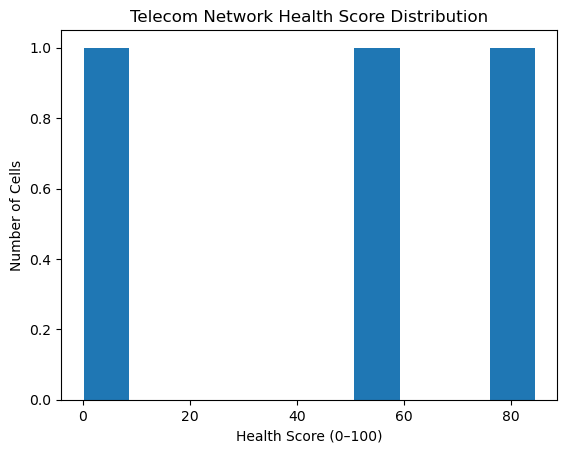

In [22]:
# Create a histogram to see how health scores are distributed
# This helps us understand network quality spread

plt.figure()

# Plot histogram of health scores
plt.hist(
    df["health_score"],  # data
    bins=10              # number of buckets
)

# Add title to chart
plt.title("Telecom Network Health Score Distribution")

# Label X-axis
plt.xlabel("Health Score (0–100)")

# Label Y-axis
plt.ylabel("Number of Cells")

# Show chart
plt.show()

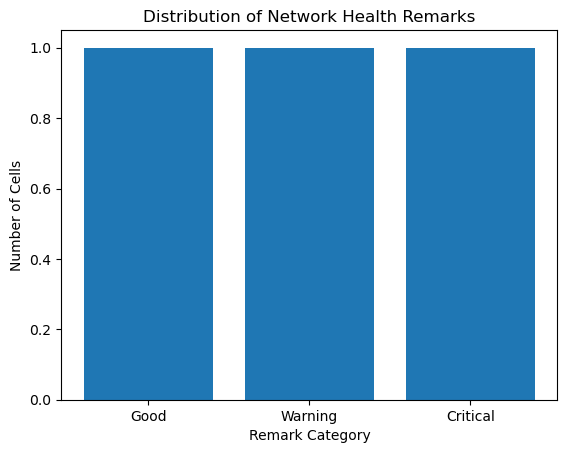

In [23]:
# Count how many cells belong to each remark category
remark_counts = df["remark"].value_counts()

# Create bar chart
plt.figure()

# Plot categories vs counts
plt.bar(
    remark_counts.index,   # X-axis categories
    remark_counts.values   # Y-axis counts
)

# Title
plt.title("Distribution of Network Health Remarks")

# X-axis label
plt.xlabel("Remark Category")

# Y-axis label
plt.ylabel("Number of Cells")

# Show chart
plt.show()

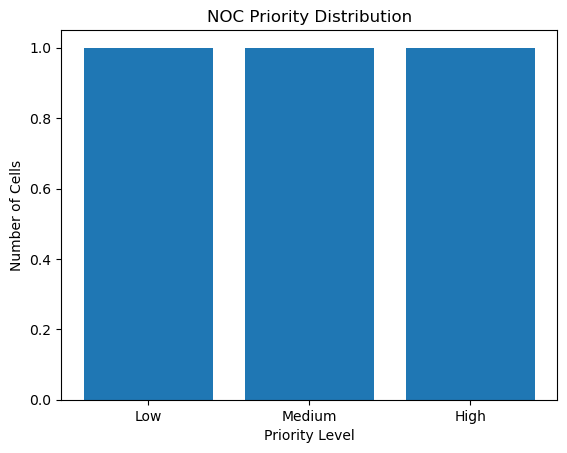

In [24]:
# Count priority levels (High / Medium / Low)
priority_counts = df["priority"].value_counts()

# Create bar chart
plt.figure()

plt.bar(
    priority_counts.index,
    priority_counts.values
)

plt.title("NOC Priority Distribution")

plt.xlabel("Priority Level")
plt.ylabel("Number of Cells")

plt.show()

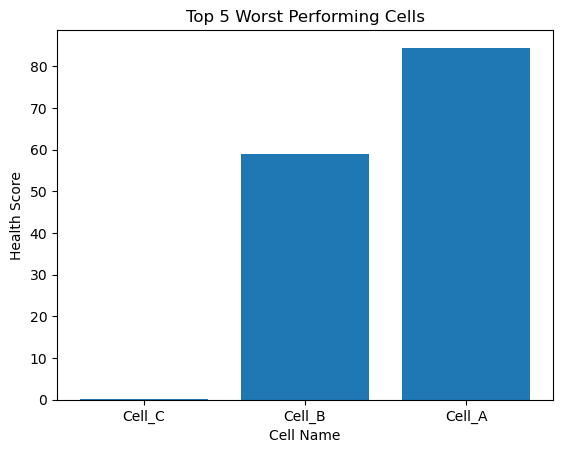

In [25]:
# Sort by lowest health score (worst first)
worst_cells = df.sort_values(
    by="health_score",
    ascending=True
).head(5)

# Create bar chart for worst cells
plt.figure()

plt.bar(
    worst_cells["cell_name"],
    worst_cells["health_score"]
)

plt.title("Top 5 Worst Performing Cells")

plt.xlabel("Cell Name")
plt.ylabel("Health Score")

plt.show()

In [26]:
# Import required libraries
# pandas = data handling
# matplotlib = visualization (used in previous part)

import pandas as pd
import matplotlib.pyplot as plt

# Create sample telecom KPI dataset
# Each row = one telecom cell

df = pd.DataFrame({

    # Cell identifier
    "cell_name": ["Cell_A", "Cell_B", "Cell_C"],

    # Latency in milliseconds (lower is better)
    "latency_ms": [15, 50, 120],

    # Packet loss percentage (lower is better)
    "packet_loss": [0.1, 1.5, 8],

    # Throughput in Mbps (higher is better)
    "throughput_mbps": [120, 70, 20],

    # PRB utilization percentage (high = congestion risk)
    "prb_utilization": [60, 75, 98]
})

# Display initial dataset
print(df)

  cell_name  latency_ms  packet_loss  throughput_mbps  prb_utilization
0    Cell_A          15          0.1              120               60
1    Cell_B          50          1.5               70               75
2    Cell_C         120          8.0               20               98


In [27]:
# Function to calculate health score for each cell

def calculate_health_score(row):

    # Start from perfect health score
    score = 100

    # Latency penalty
    score -= row["latency_ms"] * 0.2

    # Packet loss penalty
    score -= row["packet_loss"] * 5

    # Throughput penalty (lower throughput = penalty)
    score -= (150 - row["throughput_mbps"]) * 0.2

    # PRB utilization penalty
    score -= row["prb_utilization"] * 0.1

    # Ensure score does not go below 0
    score = max(score, 0)

    # Return final score
    return round(score, 2)

# Apply function to each row
df["health_score"] = df.apply(calculate_health_score, axis=1)

In [28]:
# Convert score into human-readable category

def get_remark(score):

    if score >= 90:
        return "Excellent"

    elif score >= 75:
        return "Good"

    elif score >= 50:
        return "Warning"

    else:
        return "Critical"

# Apply remark function
df["remark"] = df["health_score"].apply(get_remark)

In [29]:
# Assign operational priority based on score

def get_priority(score):

    if score < 50:
        return "High"

    elif score < 75:
        return "Medium"

    else:
        return "Low"

# Apply priority logic
df["priority"] = df["health_score"].apply(get_priority)

In [30]:
# Identify likely network issues based on KPIs

def get_root_cause(row):

    issues = []

    if row["latency_ms"] > 40:
        issues.append("High Latency")

    if row["packet_loss"] > 1:
        issues.append("Packet Loss")

    if row["throughput_mbps"] < 50:
        issues.append("Low Throughput")

    if row["prb_utilization"] > 85:
        issues.append("Congestion")

    if len(issues) == 0:
        return "Healthy"

    return " + ".join(issues)

# Apply root cause detection
df["root_cause"] = df.apply(get_root_cause, axis=1)

In [31]:
# Suggest actions based on root cause

def get_recommendation(root_cause):

    actions = []

    if "Congestion" in root_cause:
        actions.append("Check capacity & PRB utilization")

    if "Packet Loss" in root_cause:
        actions.append("Check transport/interface issues")

    if "High Latency" in root_cause:
        actions.append("Investigate core/backhaul latency")

    if "Low Throughput" in root_cause:
        actions.append("Optimize RF parameters")

    if root_cause == "Healthy":
        return "No action required"

    return " | ".join(actions)

# Apply recommendation engine
df["recommendation"] = df["root_cause"].apply(get_recommendation)

In [32]:
# Display final integrated intelligence table

print("\n===== TELECOM AI FINAL OUTPUT =====\n")

print(df)


===== TELECOM AI FINAL OUTPUT =====

  cell_name  latency_ms  packet_loss  throughput_mbps  prb_utilization  \
0    Cell_A          15          0.1              120               60   
1    Cell_B          50          1.5               70               75   
2    Cell_C         120          8.0               20               98   

   health_score    remark priority  \
0          84.5      Good      Low   
1          59.0   Warning   Medium   
2           0.2  Critical     High   

                                          root_cause  \
0                                            Healthy   
1                         High Latency + Packet Loss   
2  High Latency + Packet Loss + Low Throughput + ...   

                                      recommendation  
0                                 No action required  
1  Check transport/interface issues | Investigate...  
2  Check capacity & PRB utilization | Check trans...  


In [33]:
# Save final output for reporting or dashboard use

df.to_csv("telecom_ai_week5_output.csv", index=False)

print("File saved successfully!")

File saved successfully!
